# Запуск обучения всех моделей и сравнение логов

1. Запускает по очереди обучение REINFORCE, REINFORCE+baseline и TRPO (те же параметры, что в `scripts/train_*.sh`).
2. Строит на одном наборе графиков все метрики из папки `logs/` по каждому из трёх логов.

**Внимание:** при повторном запуске ячеек обучения файлы в `logs/` будут перезаписаны. Чтобы сохранить старые результаты, скопируйте их до повторного обучения.

In [1]:
import json
import subprocess
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root:", PROJECT_ROOT)

Project root: /app


In [7]:
# 1. Обучение REINFORCE (перезаписывает logs/training_history_reinforce.json)
# Параметры из config/settings.py
subprocess.run(
    [sys.executable, "run/train.py",
     "--num_disks", "4", "--num_sticks", "3",
     "--seed", "42",
     "--agent_method", "reinforce",
     "--reward_step", "-2.0", "--reward_goal", "100.0",
     "--reward_invalid_move", "0", "--reward_correct_placement", "2",
     "--no-use_correct_placement",
     "--num_episodes", "10000", "--max_steps", "200",
     "--log_interval", "50", "--checkpoint_interval", "1000",
     "--random_init", "--no-entropy_adaptive",
     "--learning_rate", "0.0001",
     "--entropy_coef", "0.8", "--max_grad_norm", "100.0",
     "--save_model", "model_reinforce.pth",
     "--history_path", "logs/training_history_reinforce.json"],
    cwd=PROJECT_ROOT,
    check=True,
)
print("REINFORCE done.")

2026-03-04 18:18:45 [INFO] === Starting Training Session ===
2026-03-04 18:18:45 [INFO] Method: reinforce | Disks: 4
2026-03-04 18:18:52 [INFO] episode=50 | reward=-310.48 | steps=168 | success=False | success_rate=26.0% | loss=-155.4299 | entropy=1.5909 | entropy_coef=0.8000
2026-03-04 18:18:58 [INFO] episode=100 | reward=-313.04 | steps=168 | success=False | success_rate=24.0% | loss=-172.5574 | entropy=1.5763 | entropy_coef=0.8000
2026-03-04 18:19:04 [INFO] episode=150 | reward=-303.80 | steps=164 | success=False | success_rate=26.0% | loss=-162.6431 | entropy=1.6033 | entropy_coef=0.8000
2026-03-04 18:19:11 [INFO] episode=200 | reward=-345.88 | steps=181 | success=False | success_rate=18.0% | loss=-165.8268 | entropy=1.5962 | entropy_coef=0.8000
2026-03-04 18:19:17 [INFO] episode=250 | reward=-305.20 | steps=168 | success=False | success_rate=32.0% | loss=-154.7624 | entropy=1.5876 | entropy_coef=0.8000
2026-03-04 18:19:24 [INFO] episode=300 | reward=-378.12 | steps=192 | success=F

Random seed set to: 42


KeyboardInterrupt: 

In [ ]:
# 2. Обучение REINFORCE+baseline (перезаписывает logs/training_history_reinforce_baseline.json)
# Параметры из config/settings.py
subprocess.run(
    [sys.executable, "run/train.py",
     "--num_disks", "4", "--num_sticks", "3",
     "--seed", "42",
     "--agent_method", "reinforce_baseline",
     "--reward_step", "-2.0", "--reward_goal", "4.0",
     "--reward_invalid_move", "0", "--reward_correct_placement", "2",
     "--no-use_correct_placement",
     "--num_episodes", "10000", "--max_steps", "200",
     "--log_interval", "50", "--checkpoint_interval", "1000",
     "--random_init", "--no-entropy_adaptive",
     "--learning_rate", "0.01", "--value_lr", "0.01",
     "--entropy_coef", "0.8", "--max_grad_norm", "5.0",
     "--save_model", "model_reinforce_baseline.pth",
     "--history_path", "logs/training_history_reinforce_baseline.json"],
    cwd=PROJECT_ROOT,
    check=True,
)
print("REINFORCE+baseline done.")

2026-03-04 17:29:38 [INFO] === Starting Training Session ===
2026-03-04 17:29:38 [INFO] Method: reinforce_baseline | Disks: 4
2026-03-04 17:29:46 [INFO] episode=50 | reward=-344.88 | steps=172 | success=False | success_rate=26.0% | loss=-1.9837 | entropy=1.3791 | entropy_coef=0.8000
2026-03-04 17:29:54 [INFO] episode=100 | reward=-298.92 | steps=150 | success=False | success_rate=42.0% | loss=2.7800 | entropy=1.5339 | entropy_coef=0.8000
2026-03-04 17:29:59 [INFO] episode=150 | reward=-278.44 | steps=140 | success=False | success_rate=48.0% | loss=10.7365 | entropy=1.5530 | entropy_coef=0.8000
2026-03-04 17:30:07 [INFO] episode=200 | reward=-306.96 | steps=154 | success=False | success_rate=44.0% | loss=-4.6331 | entropy=1.5931 | entropy_coef=0.8000
2026-03-04 17:30:14 [INFO] episode=250 | reward=-325.48 | steps=163 | success=False | success_rate=36.0% | loss=2.8981 | entropy=1.5619 | entropy_coef=0.8000
2026-03-04 17:30:22 [INFO] episode=300 | reward=-306.96 | steps=154 | success=Fals

Random seed set to: 42
Successfully saved training history to logs/training_history_reinforce_baseline.json
REINFORCE+baseline done.


In [4]:
# 3. Обучение TRPO (перезаписывает logs/training_history_trpo.json)
# Параметры из config/settings.py + learning rate и TRPO
subprocess.run(
    [sys.executable, "run/train.py",
     "--num_disks", "4", "--num_sticks", "3",
     "--agent_method", "trpo",
     "--seed", "42",
     "--reward_step", "-2.0", "--reward_goal", "4.0",
     "--reward_invalid_move", "0", "--reward_correct_placement", "2",
     "--no-use_correct_placement",
     "--num_episodes", "10000", "--max_steps", "200",
     "--log_interval", "50", "--checkpoint_interval", "1000",
     "--random_init", "--no-entropy_adaptive",
     "--learning_rate", "0.001",
     "--entropy_coef", "0.2", "--episodes_per_update", "10",
     "--trpo_max_kl", "0.05", "--trpo_cg_iters", "20",
     "--trpo_backtrack_iters", "15", "--trpo_backtrack_coef", "0.5",
     "--trpo_max_abs_advantage", "0.0", "--trpo_max_grad_norm_cg", "50.0",
     "--trpo_entropy_coef", "0.1", "--trpo_damping", "0.1",
     "--save_model", "model_trpo.pth",
     "--history_path", "logs/training_history_trpo.json"],
    cwd=PROJECT_ROOT,
    check=True,
)
print("TRPO done.")

2026-03-04 17:36:57 [INFO] === Starting Training Session ===
2026-03-04 17:36:57 [INFO] Method: trpo | Disks: 4
2026-03-04 17:37:12 [INFO] episode=50 | reward=-342.72 | steps=171 | success=False | success_rate=26.0% | loss=-0.0211 | entropy=1.5926 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 17:37:27 [INFO] episode=100 | reward=-317.60 | steps=159 | success=False | success_rate=32.0% | loss=-0.0266 | entropy=1.5802 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 17:37:42 [INFO] episode=150 | reward=-285.60 | steps=143 | success=False | success_rate=44.0% | loss=-0.0361 | entropy=1.5752 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 17:37:57 [INFO] episode=200 | reward=-311.76 | steps=156 | success=False | success_rate=42.0% | loss=-0.0333 | entropy=1.5653 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 17:38:12 [INFO] episode=250 | reward=-294.60 | steps=148 | success=False | success_rate=44.0% | loss=-0.0308 | entropy=1.4944 | entropy_coef=0.1000 | accepted=1.0000
2026

Random seed set to: 42
Successfully saved training history to logs/training_history_trpo.json
TRPO done.


## Графики как в plot.py: Reward, Success Rate, Steps (все модели на одной figure)

Три подграфика в столбец: (1) Total Reward per Episode, (2) Success Rate (Rolling Window 100), (3) Steps per Episode. На каждом — кривые для REINFORCE, REINFORCE+baseline и TRPO.

In [10]:
LOG_FILES = {
    "REINFORCE": PROJECT_ROOT / "logs" / "training_history_reinforce.json",
    "REINFORCE+baseline": PROJECT_ROOT / "logs" / "training_history_reinforce_baseline.json",
    "TRPO": PROJECT_ROOT / "logs" / "training_history_trpo.json",
}

def load_history(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

histories = {name: load_history(p) for name, p in LOG_FILES.items()}
missing = [n for n, h in histories.items() if h is None]
if missing:
    raise FileNotFoundError(
        "Сначала запустите ячейки обучения. Не найдены: " + ", ".join(missing)
    )

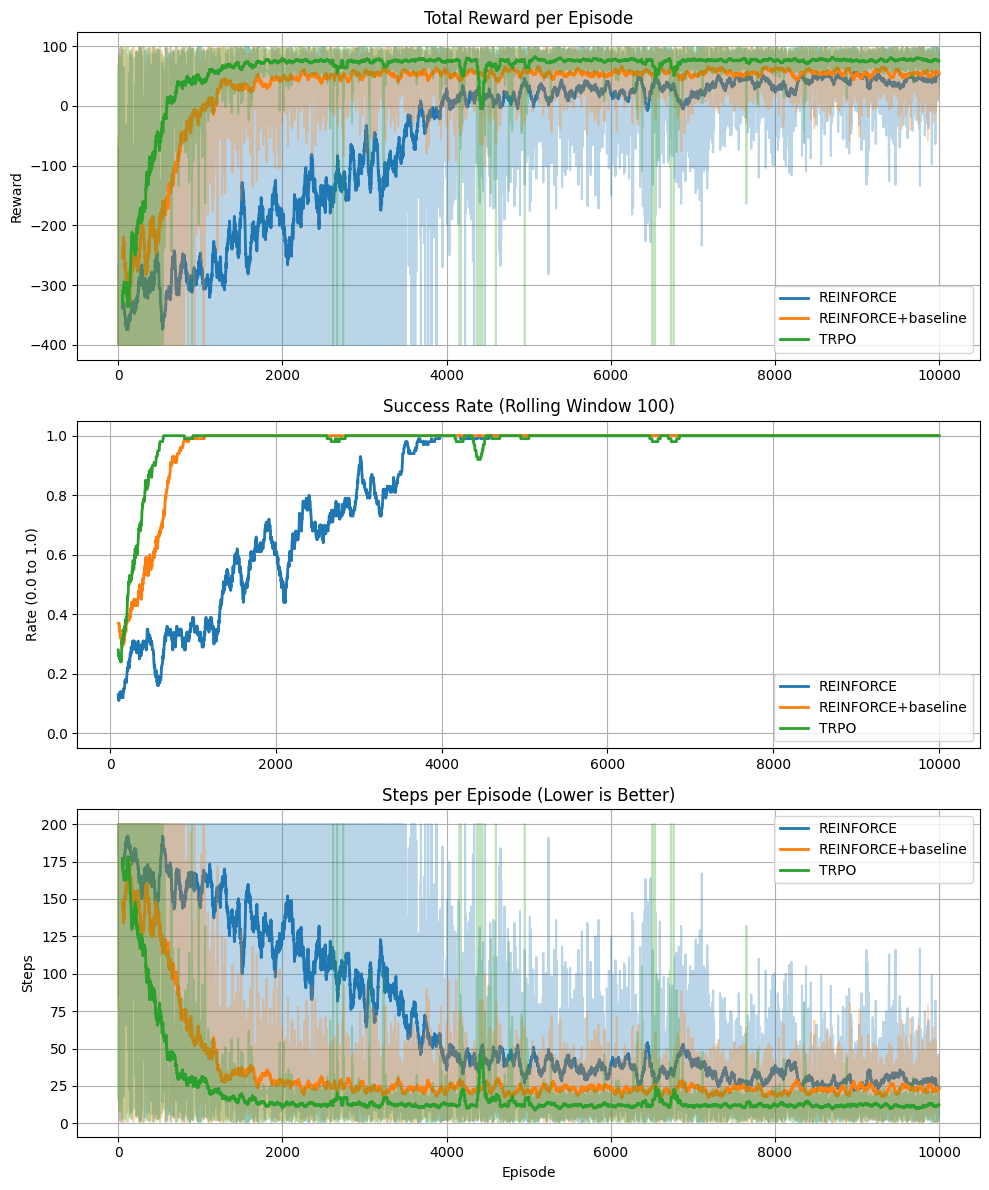

График сохранён: /app/experiments/training_curves.png


In [11]:
def moving_average(data, window=50):
    """Сглаживание графика для лучшей читаемости (как в plot.py)."""
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode="valid")

colors = {"REINFORCE": "C0", "REINFORCE+baseline": "C1", "TRPO": "C2"}

# Как в plot.py: 3 графика в столбец
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1. Total Reward per Episode
for name, history in histories.items():
    if not history:
        continue
    rewards = np.array([h["reward"] for h in history])
    ax1.plot(rewards, alpha=0.3, color=colors[name])
    ma = moving_average(rewards, 50)
    if len(ma) > 0:
        ax1.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax1.set_title("Total Reward per Episode")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# 2. Success Rate (Rolling Window 100)
for name, history in histories.items():
    if not history:
        continue
    success = np.array([h["success"] for h in history], dtype=float)
    success_smooth = moving_average(success, 100)
    if len(success_smooth) > 0:
        ax2.plot(np.arange(99, 99 + len(success_smooth)), success_smooth, color=colors[name], linewidth=2, label=name)
ax2.set_title("Success Rate (Rolling Window 100)")
ax2.set_ylabel("Rate (0.0 to 1.0)")
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
ax2.grid(True)

# 3. Steps per Episode (Lower is Better)
for name, history in histories.items():
    if not history:
        continue
    steps = np.array([h["steps"] for h in history])
    ax3.plot(steps, alpha=0.3, color=colors[name])
    ma = moving_average(steps, 50)
    if len(ma) > 0:
        ax3.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax3.set_title("Steps per Episode (Lower is Better)")
ax3.set_ylabel("Steps")
ax3.set_xlabel("Episode")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
out_path = PROJECT_ROOT / "experiments" / "training_curves.png"
plt.savefig(out_path, dpi=120)
plt.show()
print("График сохранён:", out_path)